# Approche B — Prétraitement Manuel (Split-Then-Process)

## Méthodologie
Ce notebook applique chaque étape de prétraitement **manuellement** et **séparément** :
1. **Split** (70/30 stratifié) → on isole le test set
2. **Imputation** (médiane) → `fit` sur train, `transform` sur train + test
3. **Scaling** (StandardScaler) → `fit` sur train, `transform` sur train + test
4. **SMOTE** → appliqué **uniquement** sur le train set

**Avantage** : Contrôle total sur chaque étape, visibilité pédagogique.
**Inconvénient** : Lors de la CV, le SMOTE préalable peut créer une légère fuite de données (corrigé dans la section CV avec ImbPipeline).

### Sections supplémentaires vs Approche A :
- Optimisation du **seuil de décision** pour chaque modèle (Recall ≥ 85%)
- Courbes Precision-Recall

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Outils de validation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, recall_score, f1_score, precision_recall_curve

# Gestion du déséquilibre
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline # Indispensable pour la Cross-Val propre

# Les Modèles demandés (Section 3.3 du PDF)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier

sns.set(style="whitegrid")

# 1. Chargement
try:
    data = pd.read_csv("uci-secom.csv")
    print("Données chargées.")
except:
    print("Erreur : Fichier introuvable.")

# 2. Nettoyage Préliminaire
# On supprime les colonnes inutiles avant tout
cols_to_drop = [c for c in ['Time', 'Phase'] if c in data.columns]
data = data.drop(columns=cols_to_drop)

X = data.drop(columns=['Pass/Fail'])
y = data['Pass/Fail'].replace({-1: 0}) # 0=Bon, 1=Défaut

print(f"Dimensions X : {X.shape}")

Données chargées.
Dimensions X : (1567, 590)


Train set : (1096, 590)
Test set  : (471, 590)


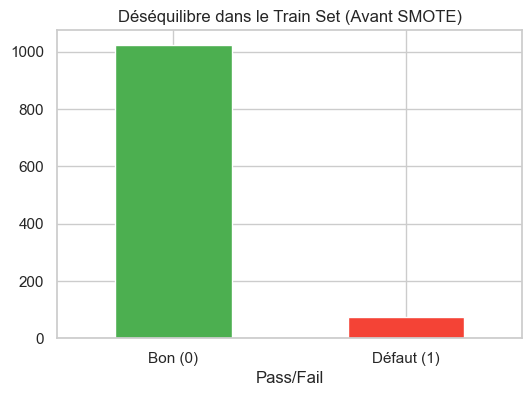

In [2]:
# SPLIT AVANT TOUT TRAITEMENT
# Train (70%) : Pour apprendre, nettoyer, et tuner.
# Test (30%) : Coffre-fort intouchable pour l'évaluation finale.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Train set : {X_train.shape}")
print(f"Test set  : {X_test.shape}")

# Visualisation du déséquilibre
plt.figure(figsize=(6, 4))
y_train.value_counts().plot.bar(color=['#4CAF50', '#F44336'])
plt.title("Déséquilibre dans le Train Set (Avant SMOTE)")
plt.xticks([0, 1], ['Bon (0)', 'Défaut (1)'], rotation=0)
plt.show()

## Prétraitement Manuel

**Règle d'or** : On `fit` sur le train, on `transform` le train ET le test. Le test ne doit **jamais** influencer les paramètres de prétraitement.

In [3]:
# 1. Imputation (Remplacer les NaN)
imputer = SimpleImputer(strategy='median')
# On FIT sur le Train, on TRANSFORM le Train et le Test
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# 2. Scaling (Mise à l'échelle)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# 3. SMOTE (Sur le TRAIN uniquement !)
print("Application de SMOTE sur le Train set...")
smote = SMOTE(random_state=42)
X_train_final, y_train_final = smote.fit_resample(X_train_scaled, y_train)

print(f"Défauts Train AVANT SMOTE : {sum(y_train==1)}")
print(f"Défauts Train APRÈS SMOTE : {sum(y_train_final==1)}")
print(f"Défauts Test (Réalité)    : {sum(y_test==1)} (On n'y touche pas !)")

Application de SMOTE sur le Train set...
Défauts Train AVANT SMOTE : 73
Défauts Train APRÈS SMOTE : 1023
Défauts Test (Réalité)    : 31 (On n'y touche pas !)


## Entraînement & Comparaison des Modèles

On entraîne les 4 modèles sur les données équilibrées (post-SMOTE) et on évalue sur le test set (scalé mais **non** SMOTÉ).

MODELE               | AUC        | RECALL     | F1        
------------------------------------------------------------
Decision Tree        | 0.5788     | 0.2258     | 0.2059
Random Forest        | 0.8271     | 0.0000     | 0.0000
AdaBoost             | 0.7337     | 0.2581     | 0.2192
Neural Network       | 0.6625     | 0.1290     | 0.1633


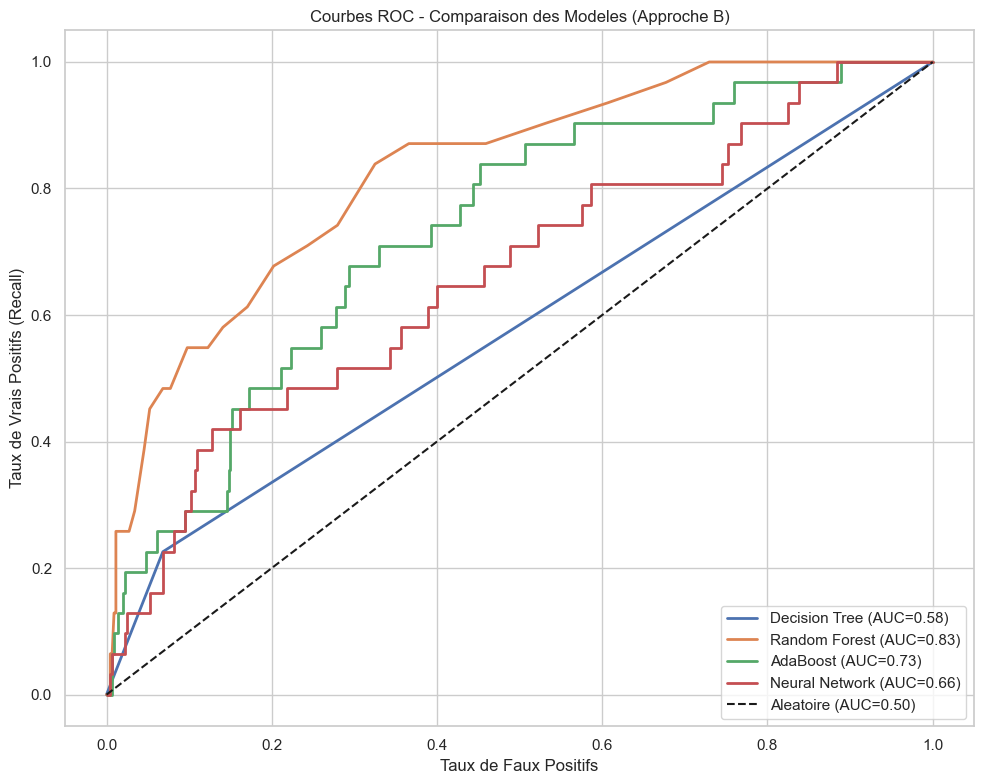


Meilleur modele (score composite = 0.4*AUC + 0.3*Recall + 0.3*F1) :
  AdaBoost - Score=0.4367
  AUC=0.7337 | Recall=0.2581 | F1=0.2192


In [8]:
# Dictionnaire des modeles
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=50, random_state=42),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(100,50), max_iter=500, random_state=42)
}

plt.figure(figsize=(10, 8))
results_b = {}

print(f"{'MODELE':<20} | {'AUC':<10} | {'RECALL':<10} | {'F1':<10}")
print("-" * 60)

for name, model in models.items():
    # Entrainement sur donnees equilibrees (post-SMOTE)
    model.fit(X_train_final, y_train_final)
    
    # Prediction sur Test Set (Scale mais NON SMOTE)
    y_pred = model.predict(X_test_scaled)
    
    # Probabilites pour ROC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = y_pred.astype(float)
        
    # Metriques
    auc_val = roc_auc_score(y_test, y_prob)
    rec_val = recall_score(y_test, y_pred)
    f1_val = f1_score(y_test, y_pred)
    
    results_b[name] = {
        'model': model,
        'auc': auc_val,
        'recall': rec_val,
        'f1': f1_val,
        'y_pred': y_pred,
        'y_prob': y_prob
    }
    
    print(f"{name:<20} | {auc_val:.4f}     | {rec_val:.4f}     | {f1_val:.4f}")
    
    # Courbe ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc_val:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Aleatoire (AUC=0.50)')
plt.title('Courbes ROC - Comparaison des Modeles (Approche B)')
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs (Recall)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Selection automatique du meilleur modele
# Score composite : 0.4*AUC + 0.3*Recall + 0.3*F1
# Un modele avec Recall=0 et F1=0 ne peut pas gagner meme avec un bon AUC
def composite_score_b(r):
    return 0.4 * r['auc'] + 0.3 * r['recall'] + 0.3 * r['f1']

best_name = max(results_b, key=lambda k: composite_score_b(results_b[k]))
print(f"\nMeilleur modele (score composite = 0.4*AUC + 0.3*Recall + 0.3*F1) :")
print(f"  {best_name} - Score={composite_score_b(results_b[best_name]):.4f}")
print(f"  AUC={results_b[best_name]['auc']:.4f} | Recall={results_b[best_name]['recall']:.4f} | F1={results_b[best_name]['f1']:.4f}")

## Validation Croisée (Robustesse)

On utilise ici `ImbPipeline` + `cross_val_score` sur les données **non prétraitées** (`X_train` original) pour mesurer la robustesse de chaque modèle de manière rigoureuse.

In [5]:
print("── VALIDATION CROISÉE (5-Fold Stratifiée) ──\n")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# On recrée les modèles pour la CV (ceux ci-dessus sont déjà entraînés)
models_cv = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=50, random_state=42),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(100,50), max_iter=500, random_state=42)
}

for name, model in models_cv.items():
    # Pipeline complet pour éviter le leakage dans la CV
    pipeline = ImbPipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('clf', model)
    ])
    
    # On valide sur X_train original (non traité) — le pipeline fait tout
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
    print(f"{name:<20} : AUC Moyen = {scores.mean():.4f} (±{scores.std():.3f})")

── VALIDATION CROISÉE (5-Fold Stratifiée) ──

Decision Tree        : AUC Moyen = 0.5361 (±0.028)
Random Forest        : AUC Moyen = 0.6503 (±0.073)
AdaBoost             : AUC Moyen = 0.6049 (±0.043)
Neural Network       : AUC Moyen = 0.6288 (±0.045)


## Optimisation du Seuil de Décision

On cherche le seuil qui garantit un Recall ≥ 85% pour chaque modèle, via la courbe **Precision-Recall**.

MODÈLE               | SEUIL      | RECALL OPT   | F1 OPT    
------------------------------------------------------------
Decision Tree        | 0.0000     | 100.00%       | 0.1235
Random Forest        | 0.1800     | 87.10%       | 0.2466
AdaBoost             | 0.4165     | 87.10%       | 0.1922
Neural Network       | 0.0000     | 87.10%       | 0.1388


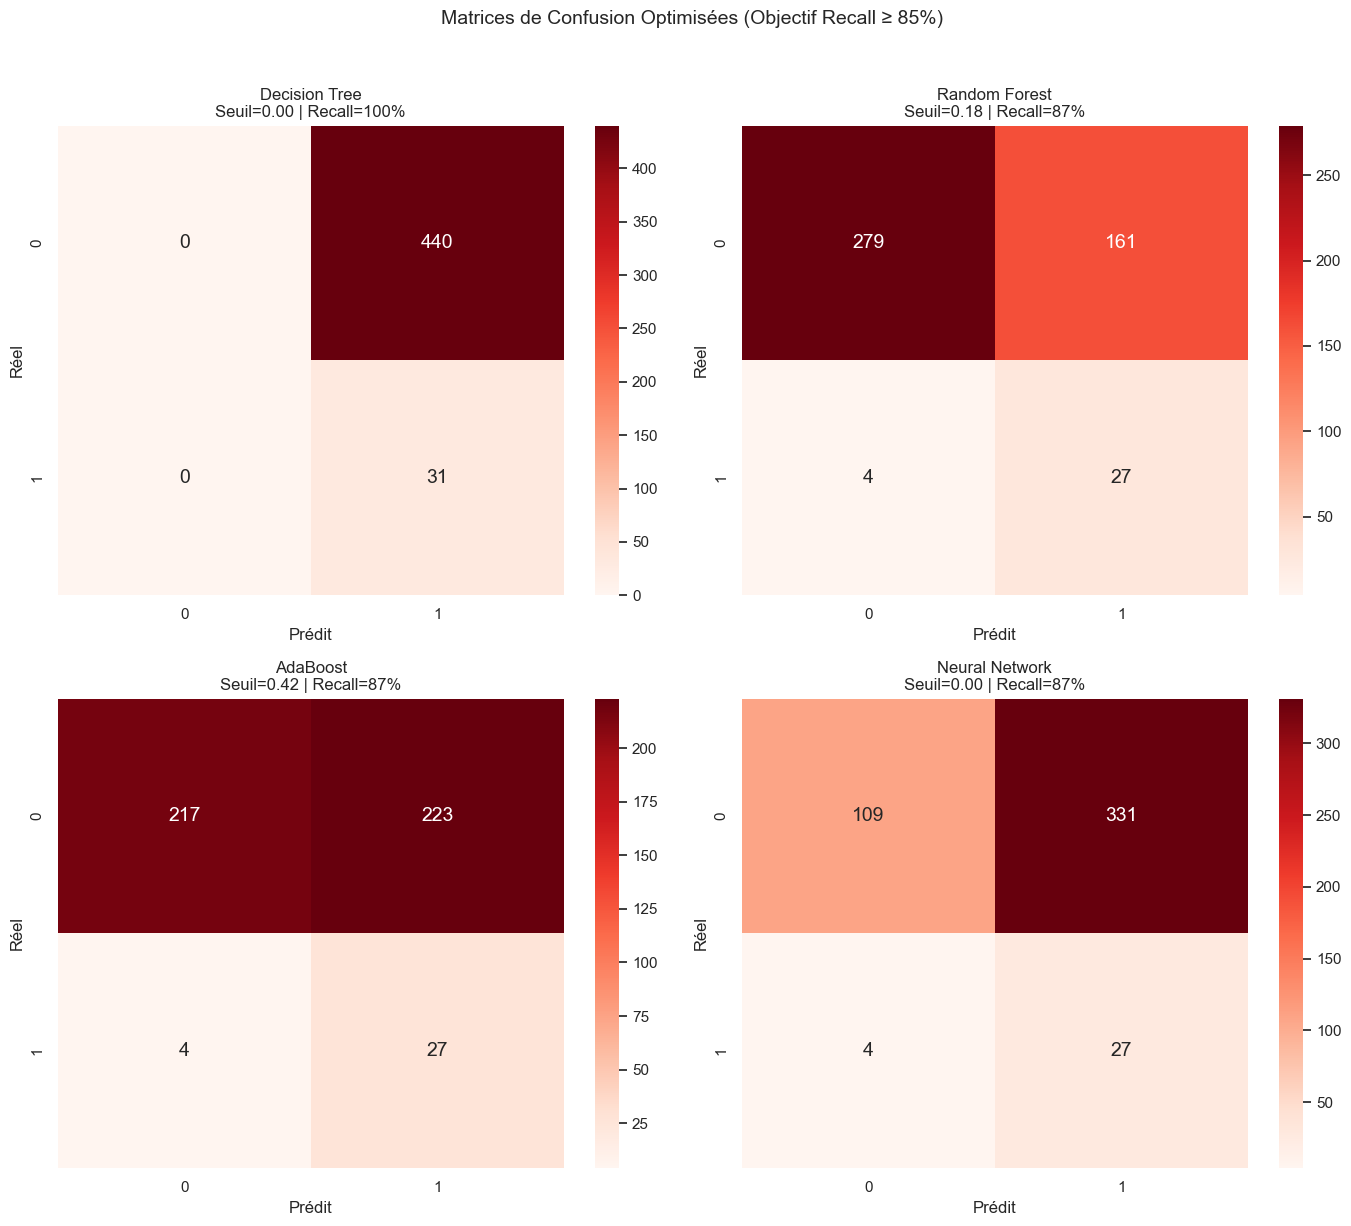

In [6]:
# Optimisation du seuil pour TOUS les modèles (Recall ≥ 85%)
target_recall = 0.85

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

print(f"{'MODÈLE':<20} | {'SEUIL':<10} | {'RECALL OPT':<12} | {'F1 OPT':<10}")
print("-" * 60)

for idx, (name, res) in enumerate(results_b.items()):
    y_prob = res['y_prob']
    
    # Courbe Precision-Recall
    precision, recall_vals, thresholds = precision_recall_curve(y_test, y_prob)
    
    # Seuil optimal pour Recall ≥ target
    valid_idx = np.where(recall_vals >= target_recall)[0]
    if len(valid_idx) > 0:
        best_idx = valid_idx[-1]
        best_thresh = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
    else:
        best_thresh = 0.5
    
    # Prédictions optimisées
    y_pred_opt = (y_prob >= best_thresh).astype(int)
    opt_recall = recall_score(y_test, y_pred_opt)
    opt_f1 = f1_score(y_test, y_pred_opt)
    
    print(f"{name:<20} | {best_thresh:.4f}     | {opt_recall:.2%}       | {opt_f1:.4f}")
    
    # Matrice de confusion optimisée
    cm = confusion_matrix(y_test, y_pred_opt)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[idx],
                annot_kws={"size": 14})
    axes[idx].set_title(f"{name}\nSeuil={best_thresh:.2f} | Recall={opt_recall:.0%}")
    axes[idx].set_ylabel('Réel')
    axes[idx].set_xlabel('Prédit')

plt.suptitle(f"Matrices de Confusion Optimisées (Objectif Recall ≥ {target_recall:.0%})",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Synthèse Finale — Approche B

In [9]:
# Tableau de synthese finale
summary_b = pd.DataFrame({
    'AUC': {n: f"{r['auc']:.4f}" for n, r in results_b.items()},
    'Recall': {n: f"{r['recall']:.4f}" for n, r in results_b.items()},
    'F1': {n: f"{r['f1']:.4f}" for n, r in results_b.items()},
})

print("=" * 62)
print("       SYNTHESE APPROCHE B (Pretraitement Manuel)")
print("=" * 62)
print(summary_b.to_string())

def composite_b(r):
    return 0.4 * r['auc'] + 0.3 * r['recall'] + 0.3 * r['f1']

best = max(results_b, key=lambda k: composite_b(results_b[k]))
print(f"\nMEILLEUR MODELE : {best}")
print(f"  Score composite = {composite_b(results_b[best]):.4f}")
print(f"  AUC    = {results_b[best]['auc']:.4f}")
print(f"  Recall = {results_b[best]['recall']:.4f}")
print(f"  F1     = {results_b[best]['f1']:.4f}")

       SYNTHESE APPROCHE B (Pretraitement Manuel)
                   AUC  Recall      F1
Decision Tree   0.5788  0.2258  0.2059
Random Forest   0.8271  0.0000  0.0000
AdaBoost        0.7337  0.2581  0.2192
Neural Network  0.6625  0.1290  0.1633

MEILLEUR MODELE : AdaBoost
  Score composite = 0.4367
  AUC    = 0.7337
  Recall = 0.2581
  F1     = 0.2192
